# 🔬 LABORATORIO N° 02 — Minería de Datos
## Metodologías de Minería de Datos: CRISP-DM Aplicado a un Problema Real

| | |
|---|---|
| **Curso** | Minería de Datos — C64893 |
| **Semana** | 2 |
| **Docente** | Pilar Rocío Sayán Mejía |
| **Institución** | TECSUP — Pasión por la Tecnología |
| **Semestre** | 2026-I |

---

### 📋 Instrucciones generales
- Ejecuta **todas** las celdas de código en orden.
- Responde las preguntas en las celdas de texto (Markdown) asignadas.
- No modifiques el código guía a menos que se indique.
- Al finalizar, descarga el notebook (.ipynb) con todas las celdas ejecutadas.

### 📚 Referencias de la sesión
- Hernández, J., Ramírez, M. J. y Ferri, C. (2004). *Introducción a la Minería de Datos*. Pearson Educación. Cap. 2.
- Provost, F. y Fawcett, T. (2013). *Data Science for Business*. O'Reilly Media. Caps. 2–3.
- Berry, M. J. A. y Linoff, G. S. (2004). *Data Mining Techniques* (2.ª ed.). Wiley. Caps. 1–2.

---
# ACTIVIDAD 1: Revisión de Conceptos — Metodologías de Minería de Datos

Complete la siguiente tabla con definiciones propias basadas en lo estudiado en la clase teórica. **No copie textualmente** de los materiales; use sus propias palabras.

| N° | Concepto / Principio | Definición con sus propias palabras |
|:---:|---|---|
| 1 | CRISP-DM (definición y significado de las siglas) | |
| 2 | SEMMA (definición y significado de las siglas) | |
| 3 | Comprensión del negocio (Business Understanding) | |
| 4 | Comprensión de los datos (Data Understanding) | |
| 5 | Preparación de datos (Data Preparation) | |
| 6 | Modelado (Modeling) | |
| 7 | Evaluación (Evaluation) | |
| 8 | Despliegue (Deployment) | |
| 9 | ¿Cuál es la principal diferencia entre CRISP-DM y SEMMA? | |
| 10 | ¿Por qué CRISP-DM es un modelo cíclico e iterativo? | |

--
# ACTIVIDAD 2: Desarrollo Práctico — Aplicación de CRISP-DM en Google Colab

En esta actividad aplicarás las **6 fases de CRISP-DM** al dataset *Telco Customer Churn* que ya exploraste en el Laboratorio 1. El objetivo es documentar y ejecutar cada fase de forma estructurada.

> 📌 *Referencia general: Provost, F. y Fawcett, T. (2013). Data Science for Business. O'Reilly Media. Caps. 2–3.*

## 🔹 Paso 1: Fase 1 — Comprensión del Negocio (Business Understanding)

Antes de tocar los datos, debemos definir el problema de negocio con claridad.

> **Contexto:** TelcoPerú es una empresa de telecomunicaciones que enfrenta una tasa de abandono (churn) del 26.5%. La gerencia quiere reducir el churn en un 15% durante el próximo trimestre mediante acciones de retención dirigidas. Tu rol es **analista de datos junior** y debes identificar los factores clave que predicen el abandono de clientes.

*Referencia: Provost, F. y Fawcett, T. (2013). Data Science for Business. O'Reilly Media. Cap. 2.*

### ✏️ Pregunta 1
**¿Cuál es el problema de negocio? Formúlalo como una pregunta analítica clara.**

*¿Que características del cliente permiten predecir si abandonará el servicio de TelcoPerú en los próximos meses?*
El problema de negocio es identificar con anticipación qué clientes tienen alta probabilidad de cancelar su contrato (churn), para que el equipo de retención pueda intervenir a tiempo. TelcoPerú tiene actualmente una tasa de churn del 26.5% y busca reducirla un 15% en el próximo trimestre.

### ✏️ Pregunta 2
**¿Qué tipo de tarea de minería de datos es este problema: clasificación, regresión, clustering o asociación? Justifica tu respuesta.**

Es un problema de clasificación binaria. La variable objetivo (Churn) tiene dos categorías: "Sí abandona" (1) o "No abandona" (0). El modelo debe aprender a asignar cada cliente a una de esas dos categorías en función de sus atributos. No es regresión (no predice un valor continuo), ni clustering (no agrupa sin etiquetas), ni asociación (no busca relaciones entre productos).

### ✏️ Pregunta 3
**¿Cuáles serían los criterios de éxito para este proyecto? Menciona al menos 2 métricas.**

1. Recall de la clase Churn (sensibilidad): el modelo debe detectar la mayor cantidad posible de clientes que realmente van a abandonar. Una meta razonable es alcanzar al menos el 70% de recall en la clase positiva.
2. Reducción real del churn: que las acciones de retención aplicadas sobre los clientes detectados por el modelo logren reducir la tasa de churn al menos un 15% en el trimestre, pasando de 26.5% a aproximadamente 22.5%.


---
## 🔹 Paso 2: Fase 2 — Comprensión de los Datos (Data Understanding)

Carga el dataset y realiza un análisis exploratorio inicial para conocer los datos disponibles.

*Referencia: Provost, F. y Fawcett, T. (2013). Data Science for Business. O'Reilly Media. Cap. 2.*

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de visualización
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

# Cargar dataset
url = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'
df = pd.read_csv(url)

# Resumen general del dataset
print('=' * 60)
print('FASE 2: COMPRENSIÓN DE LOS DATOS')
print('=' * 60)
print(f'\nDimensiones del dataset: {df.shape[0]} filas × {df.shape[1]} columnas')
print(f'\nColumnas:\n{df.columns.tolist()}')

FASE 2: COMPRENSIÓN DE LOS DATOS

Dimensiones del dataset: 7043 filas × 21 columnas

Columnas:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [ ]:
 #Tipos de datos
print('Tipos de datos:')
print(df.dtypes.value_counts())
print(f'\nVariables numéricas: {df.select_dtypes(include=[np.number]).columns.tolist()}')
print(f'\nVariables categóricas: {df.select_dtypes(include=["object"]).columns.tolist()}')

Tipos de datos:
object     18
int64       2
float64     1
Name: count, dtype: int64

Variables numéricas: ['SeniorCitizen', 'tenure', 'MonthlyCharges']

Variables categóricas: ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']


In [ ]:
# Valores nulos y problemas de calidad
print('Valores nulos por columna:')
print(df.isnull().sum()[df.isnull().sum() > 0])
if df.isnull().sum().sum() == 0:
    print('No se detectan valores nulos directamente.')
    print('\nPero revisemos TotalCharges (problema conocido del Lab 1):')
    print(f'Espacios en blanco en TotalCharges: {(df["TotalCharges"] == " ").sum()}')

Valores nulos por columna:
Series([], dtype: int64)
No se detectan valores nulos directamente.

Pero revisemos TotalCharges (problema conocido del Lab 1):
Espacios en blanco en TotalCharges: 11


Distribución de Churn:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Porcentaje de churn:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


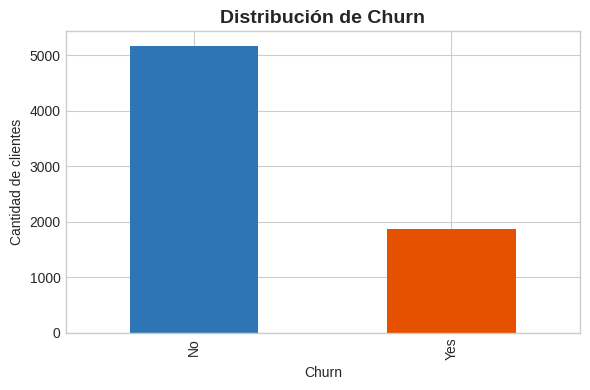

In [ ]:
# Distribución de la variable objetivo
print('Distribución de Churn:')
print(df['Churn'].value_counts())
print(f'\nPorcentaje de churn:')
print(df['Churn'].value_counts(normalize=True) * 100)

# Gráfico
fig, ax = plt.subplots(figsize=(6, 4))
df['Churn'].value_counts().plot(kind='bar', color=['#2E75B6', '#E65100'], ax=ax)
ax.set_title('Distribución de Churn', fontsize=14, fontweight='bold')
ax.set_xlabel('Churn')
ax.set_ylabel('Cantidad de clientes')
plt.tight_layout()
plt.show()

### ✏️ Pregunta 4
**¿Cuántas variables tiene el dataset? Clasifícalas en numéricas y categóricas (indica cantidad de cada tipo).**

Variables numéricas (3): SeniorCitizen, tenure, MonthlyCharges
Variables categóricas (18): customerID, gender, Partner, Dependents, etc.

### ✏️ Pregunta 5
**¿Identificas problemas de calidad en los datos? ¿Cuáles? (valores nulos, tipos incorrectos, inconsistencias).**

- La columna TotalCharges fue leída como texto porque 11 registros contienen espacios en blanco en lugar de valores numéricos. Al convertirla, esos espacios se convierten en NaN. Luego se imputan con la mediana.
- TotalCharges debería ser numérica pero estaba clasificada como categórica.
- La distribución de la variable objetivo no es equitativa.

### ✏️ Pregunta 6
**El dataset está desbalanceado?
¿Cómo podría afectar esto al entrenamiento del modelo?}**

Sí, el dataset está desbalanceado. La salida muestra:
- No churn: 5,174 registros -> 73.46%
- Churn: 1,869 registros -> 26.54%



---
## 🔹 Paso 3: Fase 3 — Preparación de Datos (Data Preparation)

Ejecuta el siguiente pipeline de preparación de datos. Esta fase consume entre el **60% y 80%** del tiempo de un proyecto real.

*Referencia: Provost, F. y Fawcett, T. (2013). Data Science for Business. O'Reilly Media. Cap. 2.*

In [ ]:
print('=' * 60)
print('FASE 3: PREPARACIÓN DE DATOS')
print('=' * 60)

# === LIMPIEZA ===
# Corregir TotalCharges (contiene espacios en blanco en lugar de valores)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f'\nValores nulos en TotalCharges después de conversión: {df["TotalCharges"].isnull().sum()}')

# Imputar nulos con la mediana
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)
print(f'Valores nulos después de imputación: {df["TotalCharges"].isnull().sum()}')
print('\n✅ Limpieza completada')

FASE 3: PREPARACIÓN DE DATOS

Valores nulos en TotalCharges después de conversión: 11
Valores nulos después de imputación: 0

✅ Limpieza completada


/tmp/ipykernel_10096/279796743.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


In [ ]:
# === TRANSFORMACIÓN ===
# Codificar variable objetivo
df['Churn_num'] = df['Churn'].map({'Yes': 1, 'No': 0})
print('Variable objetivo codificada: Churn_num (Yes=1, No=0)')

# Eliminar columna customerID (no aporta al modelo)
df_model = df.drop(columns=['customerID', 'Churn'])
print(f'\nColumna customerID eliminada')
print(f'Dimensiones actuales: {df_model.shape}')

Variable objetivo codificada: Churn_num (Yes=1, No=0)

Columna customerID eliminada
Dimensiones actuales: (7043, 20)


In [ ]:
# === CODIFICACIÓN ===
# Codificar variables categóricas con One-Hot Encoding
# separar variables numéricas y categóricas
num_cols = df_model.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df_model.select_dtypes(include=['object']).columns

# One-Hot Encoding solo para categóricas
df_encoded = pd.get_dummies(df_model, columns=cat_cols, drop_first=True)

print(f'Dimensiones después de One-Hot Encoding: {df_encoded.shape}')
print(f'\nPrimeras 10 columnas del dataset codificado:')
print(df_encoded.columns[:10].tolist())
print(f'\nÚltimas 10 columnas:')
print(df_encoded.columns[-10:].tolist())

print(f'\n✅ Preparación de datos completada')
print(f'Dataset listo para modelado: {df_encoded.shape[0]} registros × {df_encoded.shape[1]} variables')

Dimensiones después de One-Hot Encoding: (7043, 31)

Primeras 10 columnas del dataset codificado:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_num', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service']

Últimas 10 columnas:
['StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']

✅ Preparación de datos completada
Dataset listo para modelado: 7043 registros × 31 variables


### ✏️ Pregunta 7
**¿Por qué eliminamos la columna `customerID` antes del modelado? ¿Qué pasaría si la dejamos?**

Porque no tiene ningún poder predictivo ya que es un valor arbitrario que no guarda relación con el comportamiento del cliente. Si se la dejara en el dataset, el modelo podría memorizarla como un ruido que confunde el aprendizaje, aumentando el riesgo de sobreajuste y reduciendo la generalización del modelo sobre datos nuevos.

### ✏️ Pregunta 8
**¿Qué es One-Hot Encoding y por qué es necesario para variables categóricas? ¿Cuántas columnas se generaron?**

One-Hot Encoding es una técnica que convierte cada valor único de una variable categórica en una columna binaria (0 o 1). Por ejemplo, la variable Contract (que tiene valores: Month-to-month, One year, Two year) se transforma en dos columnas: Contract_One year y Contract_Two year.

Es necesario porque la mayoría de algoritmos de machine learning operan con valores numéricos. Asignar números enteros a categorías (1, 2, 3) introduciría una jerarquía artificial que no existe en los datos.

Como resultado, el dataset pasó de 20 columnas (tras eliminar customerID) a 31 columnas después del One-Hot Encoding, es decir, se generaron 11 columnas nuevas.


---
## 🔹 Paso 4: Fase 4 — Modelado (Modeling)

Aplica un modelo de clasificación para predecir el churn. Usaremos un **árbol de decisión** como primer modelo.

*Referencia: Provost, F. y Fawcett, T. (2013). Data Science for Business. O'Reilly Media. Cap. 3.*

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print('=' * 60)
print('FASE 4: MODELADO')
print('=' * 60)

# Separar features (X) y target (y)
X = df_encoded.drop(columns=['Churn_num'])
y = df_encoded['Churn_num']

print(f'\nFeatures (X): {X.shape}')
print(f'Target (y): {y.shape}')
print(f'\nDistribución del target:')
print(y.value_counts())

FASE 4: MODELADO

Features (X): (7043, 30)
Target (y): (7043,)

Distribución del target:
Churn_num
0    5174
1    1869
Name: count, dtype: int64


In [ ]:
# Dividir en entrenamiento (70%) y prueba (30%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f'Conjunto de entrenamiento: {X_train.shape[0]} registros ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Conjunto de prueba: {X_test.shape[0]} registros ({X_test.shape[0]/len(X)*100:.0f}%)')
print(f'\nDistribución en entrenamiento:')
print(y_train.value_counts(normalize=True) * 100)
print(f'\nDistribución en prueba:')
print(y_test.value_counts(normalize=True) * 100)

Conjunto de entrenamiento: 4930 registros (70%)
Conjunto de prueba: 2113 registros (30%)

Distribución en entrenamiento:
Churn_num
0    73.46856
1    26.53144
Name: proportion, dtype: float64

Distribución en prueba:
Churn_num
0    73.450071
1    26.549929
Name: proportion, dtype: float64


In [ ]:
# Entrenar árbol de decisión
modelo_arbol = DecisionTreeClassifier(max_depth=5, random_state=42)
modelo_arbol.fit(X_train, y_train)

# Predicciones
y_pred = modelo_arbol.predict(X_test)

print('✅ Modelo entrenado exitosamente')
print(f'\nParámetros del modelo:')
print(f'  Algoritmo: Árbol de Decisión')
print(f'  Profundidad máxima: {modelo_arbol.max_depth}')
print(f'  Nodos en el árbol: {modelo_arbol.tree_.node_count}')
print(f'  Features utilizados: {modelo_arbol.n_features_in_}')

✅ Modelo entrenado exitosamente

Parámetros del modelo:
  Algoritmo: Árbol de Decisión
  Profundidad máxima: 5
  Nodos en el árbol: 63
  Features utilizados: 30


### ✏️ Pregunta 9
**¿Por qué dividimos los datos en entrenamiento y prueba? ¿Qué porcentaje usamos para cada conjunto?**

La división permite evaluar el modelo sobre datos que nunca vio durante el entrenamiento, lo cual es la única forma honesta de estimar su rendimiento real. Si entrenáramos y evaluáramos sobre los mismos datos, el modelo parecería funcionar muy bien simplemente porque "memorizó" los ejemplos, pero fallaría con datos nuevos.
El código usó el 70% para entrenamiento (4,930 registros) y 30% para prueba (2,113 registros). Además, se usó stratify=y, lo que garantiza que la proporción de clases se mantenga igual en ambos subconjuntos.

### ✏️ Pregunta 10
**¿Qué significa el parámetro `max_depth=5` en el árbol de decisión? ¿Qué pasaría si no lo limitamos?**

Significa que el árbol de decisión puede crecer como máximo 5 niveles de profundidad. Esto es una restricción que previene el sobreajuste: un árbol sin límite crecería hasta memorizar perfectamente los datos de entrenamiento, incluyendo el ruido, pero generalizaría mal a datos nuevos. Con este parametro el árbol construido tiene 63 nodos, lo cual es una estructura más controlada y generalizable.

---
## 🔹 Paso 5: Fase 5 — Evaluación (Evaluation)

Evalúa el rendimiento del modelo con métricas de clasificación. No basta con que funcione técnicamente: debe cumplir los **objetivos del negocio** definidos en la Fase 1.

*Referencia: Provost, F. y Fawcett, T. (2013). Data Science for Business. O'Reilly Media. Cap. 3.*

In [ ]:
print('=' * 60)
print('FASE 5: EVALUACIÓN DEL MODELO')
print('=' * 60)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'\n📊 Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)')

FASE 5: EVALUACIÓN DEL MODELO

📊 Accuracy: 0.7880 (78.80%)


In [ ]:
# Reporte de clasificación completo
print('Reporte de clasificación:')
print('=' * 55)
print(classification_report(y_test, y_pred, target_names=['No Churn (0)', 'Churn (1)']))

Reporte de clasificación:
              precision    recall  f1-score   support

No Churn (0)       0.84      0.89      0.86      1552
   Churn (1)       0.62      0.52      0.56       561

    accuracy                           0.79      2113
   macro avg       0.73      0.70      0.71      2113
weighted avg       0.78      0.79      0.78      2113



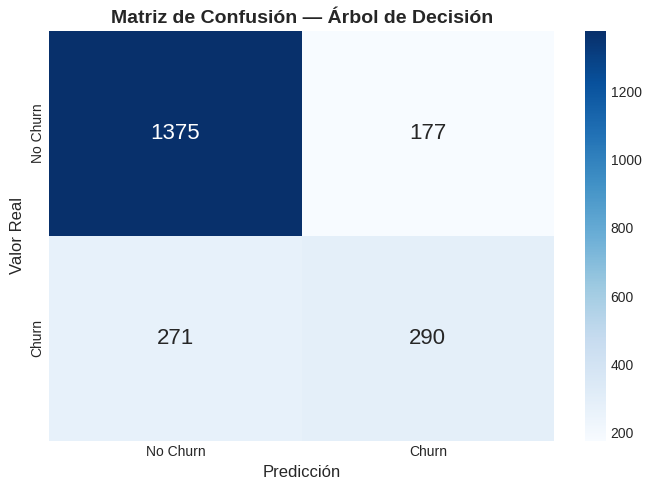

Verdaderos Negativos (TN): 1375 — Clientes que NO cancelaron, predichos correctamente
Falsos Positivos (FP):     177 — Clientes que NO cancelaron, pero el modelo dijo que sí
Falsos Negativos (FN):     271 — Clientes que SÍ cancelaron, pero el modelo NO los detectó
Verdaderos Positivos (TP): 290 — Clientes que SÍ cancelaron, detectados correctamente


In [ ]:
# Matriz de confusión visual
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'], ax=ax,
            annot_kws={'size': 16})
ax.set_title('Matriz de Confusión — Árbol de Decisión', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicción', fontsize=12)
ax.set_ylabel('Valor Real', fontsize=12)
plt.tight_layout()
plt.show()

# Interpretación numérica
print(f'Verdaderos Negativos (TN): {cm[0][0]} — Clientes que NO cancelaron, predichos correctamente')
print(f'Falsos Positivos (FP):     {cm[0][1]} — Clientes que NO cancelaron, pero el modelo dijo que sí')
print(f'Falsos Negativos (FN):     {cm[1][0]} — Clientes que SÍ cancelaron, pero el modelo NO los detectó')
print(f'Verdaderos Positivos (TP): {cm[1][1]} — Clientes que SÍ cancelaron, detectados correctamente')

### ✏️ Pregunta 11
**¿Cuál es el accuracy del modelo? ¿Es suficiente para considerar el modelo útil? Justifica.**

El modelo alcanzó un accuracy del 78.80%. A primera vista parece razonable, pero no es suficiente para este caso por sí solo. Dado que el dataset está desbalanceado (73% No churn), un modelo que simplemente predijera "No churn" siempre obtendría ~73% de accuracy sin aprender nada útil. Por eso el accuracy no es la métrica más adecuada aquí. Hay que mirar las métricas por clase.

### ✏️ Pregunta 12
**Observa la matriz de confusión: ¿Cuántos falsos negativos hay? ¿Por qué son especialmente problemáticos en un caso de predicción de churn?**

Hay 271 falsos negativos, es decir, 271 clientes que sí iban a cancelar pero el modelo predijo que no lo harían. Esto es especialmente dañino en churn porque significa que la empresa no tomará ninguna acción de retención con esos clientes, quienes terminarán abandonando el servicio sin haber recibido ninguna intervención. Desde el punto de vista del negocio, cada falso negativo es un cliente perdido que pudo haberse retenido.

### ✏️ Pregunta 13
**¿Qué métrica consideras más importante para este caso: precision o recall del churn? ¿Por qué?**

El recall es más importante porque la empresa prefiere identificar a todos los clientes en riesgo de irse, aunque algunos de esos clientes en realidad no habrían cancelado (falsos positivos). El costo de contactar a un cliente que no iba a irse es bajo (una llamada o un correo de retención). En cambio, el costo de no detectar a un cliente que sí se irá es alto: se pierde un cliente y sus ingresos futuros. Por eso se prioriza el recall (capturar todos los churn reales) sobre la precision (que todas las alarmas disparadas sean correctas).



---
## 🔹 Paso 6: Fase 6 — Despliegue (Deployment)

En un proyecto real, esta fase implica integrar el modelo en producción. Para este laboratorio, identificaremos las **variables más importantes** y haremos recomendaciones de negocio.

*Referencia: Provost, F. y Fawcett, T. (2013). Data Science for Business. O'Reilly Media. Cap. 2.*

FASE 6: DESPLIEGUE — VARIABLES MÁS IMPORTANTES


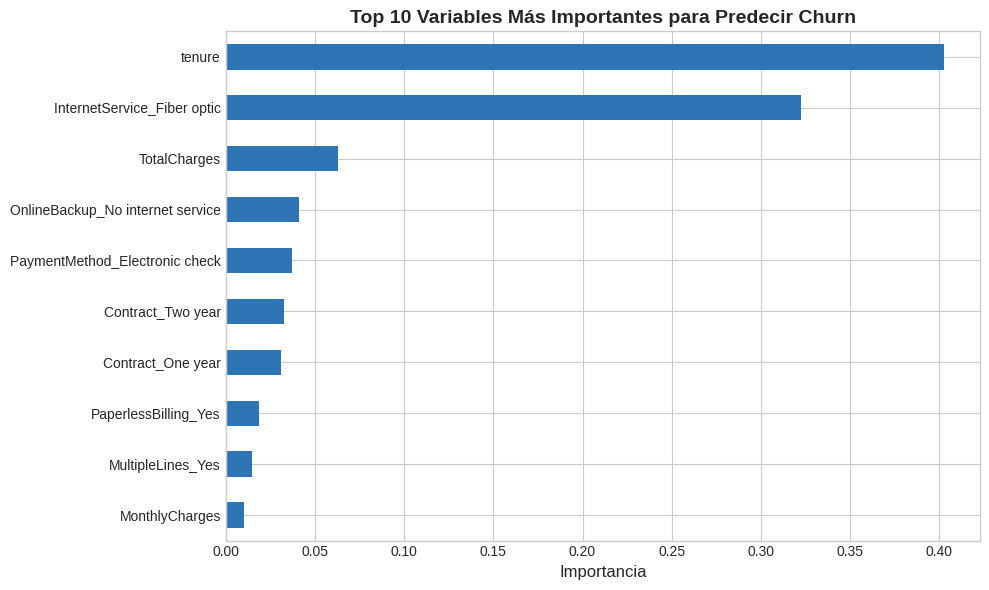

In [ ]:
print('=' * 60)
print('FASE 6: DESPLIEGUE — VARIABLES MÁS IMPORTANTES')
print('=' * 60)

# Variables más importantes del modelo
importances = pd.Series(modelo_arbol.feature_importances_, index=X.columns)
top_features = importances.nlargest(10)

# Gráfico de importancia de variables
fig, ax = plt.subplots(figsize=(10, 6))
top_features.sort_values().plot(kind='barh', color='#2E75B6', ax=ax)
ax.set_title('Top 10 Variables Más Importantes para Predecir Churn',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Importancia', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# Detalle de las variables más importantes
print('\nTop 10 predictores de churn:')
print('-' * 40)
for i, (feat, imp) in enumerate(top_features.items(), 1):
    print(f'  {i:2d}. {feat:<35s} {imp:.4f}')

# Resumen de perfiles de riesgo
print('\n' + '=' * 60)
print('PERFIL DE CLIENTE EN RIESGO DE CHURN')
print('=' * 60)
print('Basado en los resultados del modelo, un cliente con alto')
print('riesgo de abandono tiende a tener estas características:')
print('  → Contrato mes a mes (sin compromiso a largo plazo)')
print('  → Baja antigüedad (pocos meses como cliente)')
print('  → Cargos mensuales altos')
print('  → Sin servicios adicionales de protección')


Top 10 predictores de churn:
----------------------------------------
   1. tenure                              0.4027
   2. InternetService_Fiber optic         0.3222
   3. TotalCharges                        0.0632
   4. OnlineBackup_No internet service    0.0412
   5. PaymentMethod_Electronic check      0.0371
   6. Contract_Two year                   0.0327
   7. Contract_One year                   0.0310
   8. PaperlessBilling_Yes                0.0186
   9. MultipleLines_Yes                   0.0149
  10. MonthlyCharges                      0.0101

PERFIL DE CLIENTE EN RIESGO DE CHURN
Basado en los resultados del modelo, un cliente con alto
riesgo de abandono tiende a tener estas características:
  → Contrato mes a mes (sin compromiso a largo plazo)
  → Baja antigüedad (pocos meses como cliente)
  → Cargos mensuales altos
  → Sin servicios adicionales de protección


### ✏️ Pregunta 14
**¿Cuáles son las 3 variables más importantes para predecir el churn según el modelo? ¿Tienen sentido desde el punto de vista del negocio?**

Según el modelo, las 3 variables más importantes son:

1. Tenure: la antigüedad del cliente. Tiene todo el sentido: los clientes nuevos son los más propensos a irse, ya que aún no han desarrollado lealtad con la empresa y están más expuestos a comparar con la competencia.
2. InternetService_Fiber optic: los clientes con fibra óptica tienen mayor probabilidad de churn, posiblemente por expectativas más altas de calidad de servicio o por precios más elevados.
3. TotalCharges: los cargos acumulados reflejan cuánto ha pagado el cliente en total. Un monto total bajo, combinado con baja antigüedad, indica clientes recientes y potencialmente insatisfechos.


---
# ACTIVIDAD 3: Caso de Estudio — Documento CRISP-DM

Basándote en **todo el trabajo realizado** en la Actividad 2, elabora un documento resumen del proyecto CRISP-DM.

> 📌 El documento debe seguir la estructura de las 6 fases y demostrar que comprendes cómo **cada fase se conecta con la siguiente**.

### ✏️ Pregunta A
**Fase 1 — Comprensión del Negocio:** Describe el problema, los objetivos, los stakeholders y los criterios de éxito del proyecto.

**Descripción del problema**

El dengue es una de las principales emergencias de salud pública en el Perú, con un brote histórico en 2023 y alerta epidemiológica vigente en 2026. La clasificación de la severidad clínica se realiza de forma manual, lo que resulta insuficiente durante brotes masivos.  
Este proyecto propone un enfoque de **clasificación transversal poblacional**, donde, a partir de variables epidemiológicas (edad, sexo, región, semana), se identifica la severidad del caso (sin alarma, con alarma o grave), sin modelar la evolución individual del paciente.

**Objetivo**

Desarrollar un modelo de clasificación multiclase basado en XGBoost que prediga la severidad clínica del dengue según la clasificación OMS (A97.0, A97.1, A97.2).  
Además, se busca analizar los datos, comparar modelos (Regresión Logística, Random Forest, XGBoost, LightGBM) y desplegar una aplicación web en Streamlit.

**Stakeholders**

- CDC-MINSA: fortalecimiento de la vigilancia epidemiológica  
- Personal de salud: apoyo en decisiones clínicas iniciales  
- DIRESA: identificación de zonas de riesgo  
- Pacientes: mejor clasificación y atención oportuna  

**Criterios de éxito**

El modelo debe alcanzar un **F1-score macro > 0.55** en datos de prueba.  
Se prioriza el desempeño en la clase grave (A97.2), debido a su impacto clínico.  
El proyecto se completa con un **dashboard funcional en Streamlit** con predicción en tiempo real.

------------------------------------------------
### ✏️ Pregunta B
**Fase 2 — Comprensión de los Datos:** Describe el dataset, las variables más relevantes, los problemas de calidad encontrados y los hallazgos del EDA.

**Descripción del dataset**

Se utiliza el dataset público de vigilancia epidemiológica del dengue del CDC-MINSA (2000–2024), con ~794k registros y 14 variables por caso notificado.

**Variables relevantes**

- Geográficas: departamento, provincia, distrito  
- Temporales: año, semana epidemiológica  
- Demográficas: edad, sexo  
- Objetivo: diagnostic (A97.0, A97.1, A97.2)  
- Variables administrativas (localidad, localcod, diresa) fueron descartadas  

**Problemas de calidad**

- Error de encoding (BOM) en "departamento" → corregido  
- Edad en múltiples unidades (años, meses, días) → convertida a años  
- Nulos en variables no relevantes → eliminadas  
- Nulos mínimos en variables críticas → filas eliminadas  

**Distribución del target**

Dataset altamente desbalanceado:  
- A97.0: 88.5%  
- A97.1: 11.1%  
- A97.2: 0.4%  
→ Se requiere balanceo (SMOTE)

**Hallazgos del EDA**
- Estacionalidad clara (semanas 15–25)  
- Concentración geográfica (Piura, Loreto, etc.)  
- Mayor edad promedio en casos graves  
- Pico histórico en 2023 (mayor presión epidemiológica)

---------------------------------------------------------
### ✏️ Pregunta C
**Fase 3 — Preparación de Datos:** Explica qué transformaciones realizaste y por qué. Menciona limpieza, codificación y selección de variables.

**Limpieza de datos**

- Corrección del nombre de columna (BOM) en "departamento"  
- Eliminación de columnas irrelevantes: localidad, localcod, diresa  
- Eliminación de filas con nulos en variables críticas (<0.003%)  

**Transformaciones**

- Conversión de edad a años (edad_anios) desde A/M/D  
- Filtrado de valores fuera del rango (0–120 años)  
- Mapeo del target: A97.0→0, A97.1→1, A97.2→2  
- Codificación de sexo (F→0, M→1)  
- Codificación de variables geográficas con LabelEncoder (por columna)  

**Feature Engineering**
- casos_semana: intensidad del brote por región  
- Variables lag (lag_1, lag_2, lag_3) para capturar comportamiento previo  
- Rolling (media y suma 4 semanas) evitando data leakage  
- Variables temporales: mes y trimestre  

**Selección de variables**

Se definieron 15 features finales, excluyendo variables redundantes o auxiliares (enfermedad, tipo_edad, edad, fecha).

**Preparación para modelado**

- Split temporal: train (2018–2021), validación (2022), test (2023–2024)  
- Balanceo con SMOTE aplicado solo en entrenamiento para evitar data leakage


----------------------------------------------------
### ✏️ Pregunta D
**Fase 4 — Modelado:** ¿Qué algoritmo usaste? ¿Qué hiperparámetros configuraste? ¿Por qué elegiste ese modelo?

**Respuesta:**

*(escribe aquí)*
### ✏️ Pregunta E
**Fase 5 — Evaluación:** ¿Qué métricas obtuviste? ¿El modelo cumple los objetivos de negocio definidos en la Fase 1? ¿Qué limitaciones tiene?

**Respuesta:**

*(escribe aquí)*
### ✏️ Pregunta F
**Fase 6 — Despliegue:** ¿Cómo implementarías este modelo en la empresa? Propón un sistema de alertas tempranas y 3 acciones concretas de retención basadas en los hallazgos.

**Respuesta:**

*(escribe aquí)*


---
# 📝 CONCLUSIONES

Escriba las conclusiones técnicas y de aprendizaje obtenidas tras la práctica:

1. *(escribe aquí)*

2. *(escribe aquí)*

3. *(escribe aquí)*


---
### 📚 Referencias bibliográficas

- Berry, M. J. A. y Linoff, G. S. (2004). *Data Mining Techniques: For Marketing, Sales, and Customer Relationship Management* (2.ª ed.). Wiley.
- Hernández, J., Ramírez, M. J. y Ferri, C. (2004). *Introducción a la Minería de Datos*. Pearson Educación.
- Provost, F. y Fawcett, T. (2013). *Data Science for Business*. O'Reilly Media.
- Gutman, A. J. y Goldmeier, J. (2021). *Becoming a Data Head*. Wiley.

---
*Minería de Datos — Semana 2 | TECSUP 2026-I | Prof. Pilar Rocío Sayán Mejía*